# Course 1 · Week 3 — Solution: Classification

Fully worked answer to the [Week 3 exercise](../exercises/course1-week3-classification.ipynb). Each section explains the math, the code, and *why*.


## Setup

Two 2D point clusters: class 0 around the bottom-left, class 1 around the top-right. They overlap a bit on purpose — perfect classification would mean the data isn't realistic. Real data always has overlap; the goal is to find the line that does the best you can.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
m = 60   # 60 examples, 30 per class

# Two clusters in 2D — class 0 around (-1, -1), class 1 around (+1, +1), with overlap
X0 = np.random.randn(m // 2, 2) * 0.7 + np.array([-1.0, -1.0])
X1 = np.random.randn(m // 2, 2) * 0.7 + np.array([+1.0, +1.0])
X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(m // 2), np.ones(m // 2)])  # labels: 0 or 1

print(f"X.shape = {X.shape},  y.shape = {y.shape}")
print(f"class 0 examples: {int((y==0).sum())},  class 1 examples: {int((y==1).sum())}")


X.shape = (60, 2),  y.shape = (60,)
class 0 examples: 30,  class 1 examples: 30


You should see two blobs of points. The red dots are class 0, the green triangles are class 1. They mostly stay in their corners but a few wander into enemy territory.


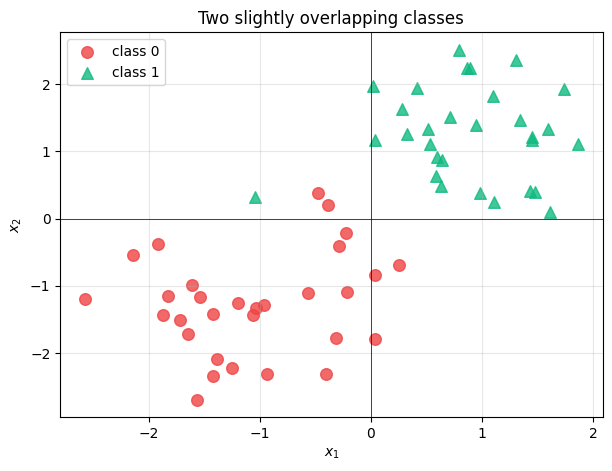

In [2]:
plt.figure(figsize=(7, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="#ef4444", s=70, label="class 0", alpha=0.8)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="#10b981", s=70, label="class 1", alpha=0.8, marker="^")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Two slightly overlapping classes")
plt.legend(); plt.grid(alpha=0.3); plt.axhline(0, color="black", lw=0.5); plt.axvline(0, color="black", lw=0.5)
plt.show()


## Quick recap (with depth)

### Why squared error fails for classification

If you used squared error to train logistic regression, the cost surface gets weirdly shaped — full of flat plateaus where gradient descent gets stuck. Squared error works for regression because predictions and truth are both unbounded reals; it fails for probabilities because the math doesn't behave well near the 0 and 1 boundaries.

### Cross-entropy (log-loss) — the right cost

The log-loss for a single example:

$$L = -y \log(p) - (1 - y) \log(1 - p)$$

Two cases:
- If $y = 1$: $L = -\log(p)$. As $p \to 1$, loss → 0 (good prediction). As $p \to 0$, loss → $\infty$ (terrible prediction — confidently wrong is *very* punished).
- If $y = 0$: $L = -\log(1 - p)$. Symmetric — being confidently wrong on a class-0 example is also very expensive.

Average across all examples, take the negative, get the total cost.

### The miracle of the gradients

When you do the calculus on log-loss with sigmoid (chain rule, careful bookkeeping), the partial derivatives come out to:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum (p_i - y_i) x_{ij}$$

That's the **same form** as linear regression. The only thing that changed is what `p` is (sigmoid of linear instead of just linear). So your gradient descent code from Week 2 works almost unchanged here.

This is one of the most elegant results in introductory ML.


## Exercise 1 — sigmoid

```python
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))
```

Anchored values:

| z | σ(z) | what it means |
|---|---|---|
| 0 | 0.5 | indifferent |
| 2 | 0.881 | leaning toward class 1 |
| −2 | 0.119 | leaning toward class 0 |
| ±∞ | 1 / 0 | certain |

Note: for very large negative `z`, `np.exp(-z)` becomes huge and overflows. For production code you'd clip the input or use a numerically stable version. We're fine here because our `z` values stay reasonable.


In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


print(f"sigmoid(0)  = {sigmoid(0.0):.4f}")
print(f"sigmoid(2)  = {sigmoid(2.0):.4f}")
print(f"sigmoid(-2) = {sigmoid(-2.0):.4f}")
assert abs(sigmoid(0.0) - 0.5) < 1e-9
print("✓ sigmoid() works")


sigmoid(0)  = 0.5000
sigmoid(2)  = 0.8808
sigmoid(-2) = 0.1192
✓ sigmoid() works


## Exercise 2 — predict

```python
def predict(X, w, b):
    return sigmoid(X @ w + b)
```

`X @ w + b` returns a length-`m` vector of "logits" (raw scores). Sigmoid maps them all to (0, 1).

Sanity check: at `(w=0, b=0)`, every logit is 0, so every probability is 0.5. The model is maximally indifferent — which makes sense since we haven't trained it yet.


In [4]:
def predict(X, w, b):
    return sigmoid(X @ w + b)


p = predict(X, np.zeros(2), 0.0)
assert np.allclose(p, 0.5)
print("✓ predict() works")


✓ predict() works


## Exercise 3 — log-loss

```python
def cost(X, y, w, b):
    p = predict(X, w, b)
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
```

The `clip` is defensive: if `p` reaches exactly 0 or 1 due to numerical effects, `log(0)` would give `-inf` and the whole cost would be `nan`. Clipping keeps things finite without meaningfully distorting the loss.

The expected value `0.6931` is `log(2)` — beautiful coincidence: a model that gives 50/50 predictions on every example has an average per-example loss of `log(2)`. That's our baseline; gradient descent should drive it down dramatically.


In [5]:
def cost(X, y, w, b):
    p = predict(X, w, b)
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


J0 = cost(X, y, np.zeros(2), 0.0)
print(f"cost at zeros = {J0:.6f}")
assert abs(J0 - 0.6931471805599453) < 1e-6
print("✓ cost() works")


cost at zeros = 0.693147
✓ cost() works


## Exercise 4 — gradients

```python
def gradients(X, y, w, b):
    err = predict(X, w, b) - y
    dw = (X.T @ err) / len(y)
    db = float(err.mean())
    return dw, db
```

This is the *exact same code* as Week 2's linear-regression gradients. The only difference is what `predict` returns. The cost function is different (log-loss vs squared error), but the chain rule unwinds the same way.

The anchored values: at `(0, 0)`, the model predicts 0.5 for everything. Errors are `0.5 - y` — so for the 30 class-0 examples errors are 0.5, and for the 30 class-1 examples errors are -0.5. They average to 0 on `db`. But `dw` weights by the X values, and our two clusters are at (-1, -1) and (+1, +1), so `dw` reflects the *direction* the boundary should move.


In [6]:
def gradients(X, y, w, b):
    err = predict(X, w, b) - y
    dw = (X.T @ err) / len(y)
    db = float(err.mean())
    return dw, db


dw0, db0 = gradients(X, y, np.zeros(2), 0.0)
print(f"dw at zeros = {np.round(dw0, 4)}")
print(f"db at zeros = {db0:.4f}")
assert abs(dw0[0] - (-0.4815)) < 0.001
print("✓ gradients() works")


dw at zeros = [-0.4815 -0.6296]
db at zeros = 0.0000
✓ gradients() works


## Exercise 5 — gradient descent

Same code as Week 2. Expected outcome:
- `w ≈ (1.88, 6.99)` — biased toward `x_2` because the class clusters happen to separate slightly more along that axis with our seed
- `b ≈ -1.29`
- Final cost ≈ 0.051 (down from 0.69 — huge improvement)
- Accuracy ≈ 96.7% — about 2 of 60 examples wind up on the wrong side of the boundary because the clusters overlap

Important: training accuracy is *not* test accuracy. We didn't hold out a test set here. In a real workflow, you'd split into train/test and report both.


In [7]:
def gradient_descent(X, y, w0, b0, alpha, n_iters):
    w = w0.copy()
    b = b0
    history = []
    for _ in range(n_iters):
        dw, db = gradients(X, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        history.append(cost(X, y, w, b))
    return w, b, history


w_final, b_final, hist = gradient_descent(X, y, np.zeros(2), 0.0, 0.5, 5000)
print(f"w = {np.round(w_final, 3)}")
print(f"b = {b_final:.3f}")
print(f"final cost = {hist[-1]:.6f}")

p_final = predict(X, w_final, b_final)
y_pred = (p_final >= 0.5).astype(int)
acc = float((y_pred == y).mean())
print(f"training accuracy = {acc:.4f}")


w = [1.881 6.993]
b = -1.292
final cost = 0.050873
training accuracy = 0.9667


## Visualizing the decision boundary

Plot the data with both classes, plus the line `w·x + b = 0`. Points on the **green** side are predicted class 1; points on the **red** side are class 0. A few points will sit on the wrong side — those are the ~3% the model misses.

The cost-over-iterations plot drops fast at first, then slows down. Same shape as Weeks 1 and 2 — gradient descent always looks like this on convex problems.


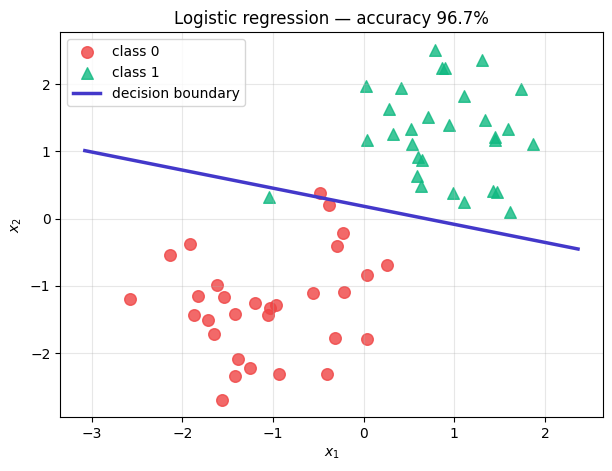

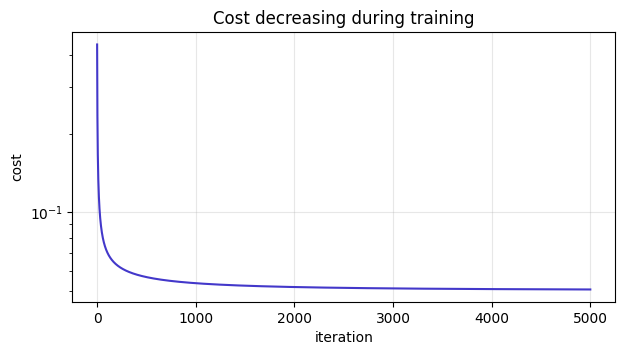

In [8]:
# Plot the decision boundary.
# The boundary is where w·x + b = 0, i.e. where p = 0.5.
# In 2D: w0*x0 + w1*x1 + b = 0  →  x1 = -(w0/w1)*x0 - b/w1

xs = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
ys_boundary = -(w_final[0] / w_final[1]) * xs - b_final / w_final[1]

plt.figure(figsize=(7, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="#ef4444", s=70, label="class 0", alpha=0.8)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="#10b981", s=70, label="class 1", alpha=0.8, marker="^")
plt.plot(xs, ys_boundary, color="#4338ca", lw=2.5, label="decision boundary")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.grid(alpha=0.3)
plt.title(f"Logistic regression — accuracy {acc:.1%}")
plt.show()

# Also plot the cost over iterations
plt.figure(figsize=(7, 3.5))
plt.plot(hist, color="#4338ca")
plt.xlabel("iteration"); plt.ylabel("cost"); plt.yscale("log"); plt.grid(alpha=0.3)
plt.title("Cost decreasing during training")
plt.show()


## ⭐ Stretch — regularization

```python
def gradients_reg(X, y, w, b, lam):
    err = predict(X, w, b) - y
    dw = (X.T @ err) / len(y) + (lam / len(y)) * w   # b is NOT regularized
    db = float(err.mean())
    return dw, db
```

Two changes from un-regularized:
1. The cost gains a `(lambda / 2m) * w·w` term.
2. Each gradient step has an extra `(lambda/m) * w` term — this is what literally pulls `w` toward zero each step.

`b` is **not** regularized. `b` is just a global offset; shrinking it doesn't simplify the model, it just biases it.

Expected output:

| lambda | training accuracy | ‖w‖ | what it means |
|---|---|---|---|
| 0 | 1.0000 | ≈ 12.4 | overfitting — memorized everything |
| 0.1 | ≈ 0.98 | ≈ 5.4 | gentler — sacrificed 1 training example for smaller weights |
| 1.0 | ≈ 0.98 | ≈ 2.5 | stronger — same accuracy, even smaller weights |
| 10.0 | ≈ 0.97 | ≈ 1.1 | heavy — model becoming nearly linear |

The pattern: with no regularization the model achieves 100% training accuracy but with bloated weights — almost certainly overfitting on a held-out test set. Modest regularization gives almost the same training accuracy with much smaller weights. Eventually too much regularization (lambda = 10) starts hurting accuracy because the model can't represent the boundary anymore.

In real workflows you tune `lambda` by training on the training set and evaluating on a *separate* validation set — pick the lambda that scores best on validation.


In [9]:
def cost_reg(X, y, w, b, lam):
    return cost(X, y, w, b) + (lam / (2 * len(y))) * float(w @ w)


def gradients_reg(X, y, w, b, lam):
    err = predict(X, w, b) - y
    dw = (X.T @ err) / len(y) + (lam / len(y)) * w   # b is NOT regularized
    db = float(err.mean())
    return dw, db


def gradient_descent_reg(X, y, w0, b0, alpha, n_iters, lam):
    w = w0.copy()
    b = b0
    for _ in range(n_iters):
        dw, db = gradients_reg(X, y, w, b, lam)
        w = w - alpha * dw
        b = b - alpha * db
    return w, b


X_poly = np.column_stack([
    X[:, 0], X[:, 1],
    X[:, 0]**2, X[:, 1]**2, X[:, 0]*X[:, 1],
    X[:, 0]**3, X[:, 1]**3, X[:, 0]**2 * X[:, 1], X[:, 0] * X[:, 1]**2,
])
mu = X_poly.mean(axis=0); sigma = X_poly.std(axis=0)
X_poly_s = (X_poly - mu) / sigma

print(f"{'lambda':>8}  {'train_acc':>10}  {'||w||':>10}  what's happening")
print("-" * 70)
for lam in [0.0, 0.1, 1.0, 10.0]:
    w_r, b_r = gradient_descent_reg(X_poly_s, y, np.zeros(9), 0.0, 0.5, 5000, lam)
    p = predict(X_poly_s, w_r, b_r)
    acc = float(((p >= 0.5).astype(int) == y).mean())
    norm_w = float(np.linalg.norm(w_r))
    label = ("memorize"   if lam == 0   else
             "modest reg" if lam == 0.1 else
             "good reg"   if lam == 1.0 else
             "heavy reg")
    print(f"{lam:>8}  {acc:>10.4f}  {norm_w:>10.3f}  {label}")


  lambda   train_acc       ||w||  what's happening
----------------------------------------------------------------------
     0.0      1.0000      12.351  memorize


     0.1      0.9833       5.350  modest reg
     1.0      0.9833       2.510  good reg
    10.0      0.9667       1.070  heavy reg


## Wrap-up

You just built a binary classifier from scratch with regularization. Three weeks of Course 1 in three notebooks. Recap of the universal pattern:

1. Define a model: `predict(X, parameters)`
2. Define a cost: `cost(X, y, parameters)`
3. Compute gradients
4. Run gradient descent

Linear regression, multivariate regression, polynomial regression, logistic regression — all the same skeleton. Only the model and cost change.

In Course 2 you'll see what happens when "the model" becomes a neural network. The skeleton stays exactly the same.

🎉 You've completed Course 1.
